# 实验-真人呼吸频率估计



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def find_project_root() -> Path:
    """向上查找含 src/ 的项目根目录。"""
    start = Path.cwd().resolve()
    for path in [start, *start.parents]:
        if (path / "src").is_dir():
            return path
    raise FileNotFoundError("未找到项目根目录（缺少 src/ 目录）")

PROJECT_ROOT = find_project_root()

# -----------------------
# 1) 数据（来自你截图）
# -----------------------
subjects = ["shen", "jingwei", "yiming", "cheng"]
subject_ids = np.arange(1, len(subjects) + 1)
true_bpms = [9, 11, 14]

# est = {
#     "CS": {
#         9:  [9.684, 9.318, 9.468, 9.412],
#         11: [12.414, 12.801, 12.234, 11.754],
#         14: [14.352, 14.118, 14.232, 14.406],
#     },
#     "DF": {
#         9:  [9.080, 8.718, 8.868, 8.832],
#         11: [12.102, 12.300, 11.700, 11.500],
#         14: [14.718, 14.828, 15.090, 15.020],
#     }
# }

est = {
    "CS": {
        9:  [9.684, 9.318, 9.468, 9.412],
        11: [12.414, 12.801, 12.234, 11.754],
        # 14: [14.352, 14.118, 14.232, 14.406],
        14: [14.718, 14.828, 15.090, 15.020],
    },
    "DF": {
        9:  [9.080, 8.718, 8.868, 8.832],
        11: [12.102, 12.300, 11.700, 11.500],
        14: [14.352, 14.118, 14.232, 14.406],
    }
}

def percent_abs_error(est_list, true_bpm):
    est_arr = np.array(est_list, dtype=float)
    return np.abs(est_arr - true_bpm) / true_bpm * 100.0

# -----------------------
# 2) 样式：默认字体 + 深色 + 黑边框
# -----------------------
colors = {"CS": "#0B3D91", "DF": "#0B6E4F"}  # 深蓝/深绿
markers = {"CS": "o", "DF": "s"}

# 导出 PDF 时文字可编辑（不影响字体选择，仍是默认字体族）
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.8,
})

# -----------------------
# 3) 画图（3 个子图：9/11/14）
# -----------------------
# fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
# offset = 0.13

# # 统一 y 上限
# all_err = []
# for m in ["CS", "DF"]:
#     for tbpm in true_bpms:
#         all_err.append(percent_abs_error(est[m][tbpm], tbpm))
# ymax = float(np.max(np.concatenate(all_err)))
# ymax = max(5.0, ymax * 1.15)

# for ax, tbpm in zip(axes, true_bpms):
#     x_cs = subject_ids - offset
#     x_df = subject_ids + offset

#     y_cs = percent_abs_error(est["CS"][tbpm], tbpm)
#     y_df = percent_abs_error(est["DF"][tbpm], tbpm)

#     ax.scatter(
#         x_cs, y_cs,
#         s=42, marker=markers["CS"],
#         facecolors=colors["CS"], edgecolors="black", linewidths=0.8,
#         label="CS", zorder=3
#     )
#     ax.scatter(
#         x_df, y_df,
#         s=42, marker=markers["DF"],
#         facecolors=colors["DF"], edgecolors="black", linewidths=0.8,
#         label="DF", zorder=3
#     )

#     ax.set_title(f"Target = {tbpm} BPM", fontsize=10)
#     ax.set_xlim(0.5, 4.5)
#     ax.set_xticks(subject_ids)
#     ax.set_xticklabels([str(i) for i in subject_ids])
#     ax.set_ylim(0, ymax)

#     ax.grid(True, axis="y", linewidth=0.6, alpha=0.6)
#     ax.grid(False, axis="x")

# axes[0].set_ylabel("Relative absolute error (%)")
# fig.supxlabel("Subject")

# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.05))

# plt.tight_layout()
# plt.savefig("breathing_percent_error_matplotlib.pdf", bbox_inches="tight")
# plt.savefig("breathing_percent_error_matplotlib.svg", bbox_inches="tight")
# plt.show()

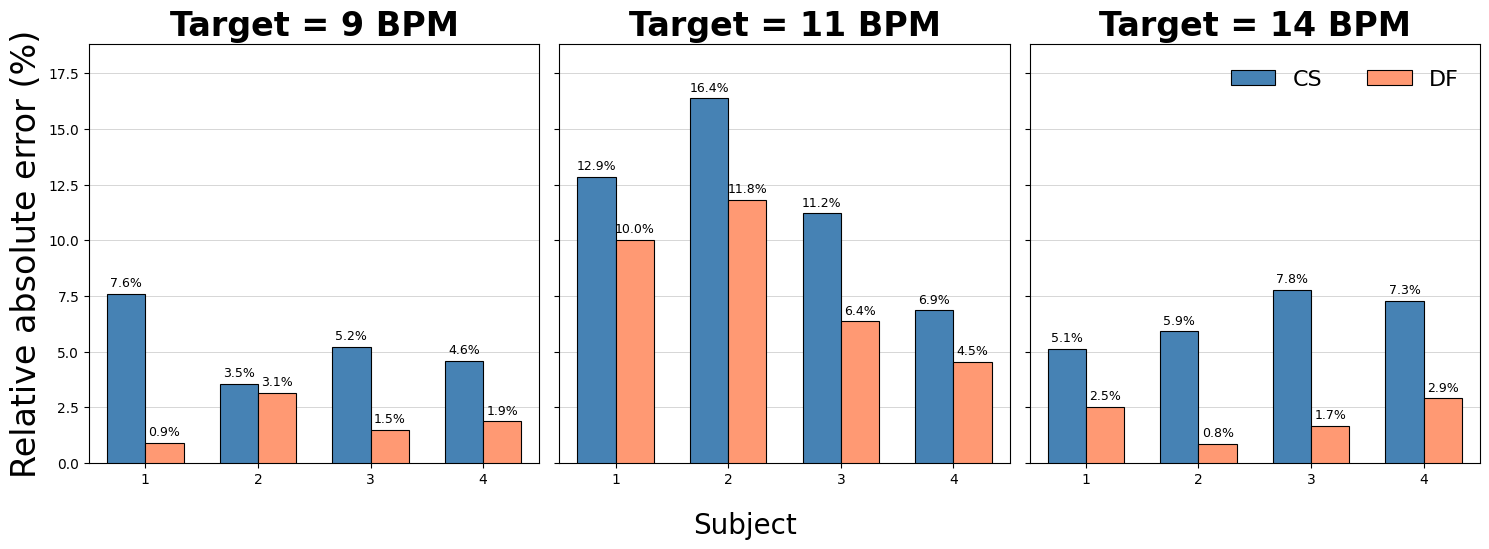

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
out_dir = PROJECT_ROOT / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

# -----------------------
# 1) 数据（来自你截图）
# -----------------------
subjects = ["shen", "jingwei", "yiming", "cheng"]
subject_ids = np.arange(1, len(subjects) + 1)
true_bpms = [9, 11, 14]

# est = {
#     "CS": {
#         9:  [9.684, 9.318, 9.468, 9.412],
#         11: [12.414, 12.801, 12.234, 11.754],
#         14: [14.352, 14.118, 14.232, 14.406],
#     },
#     "DF": {
#         9:  [9.080, 8.718, 8.868, 8.832],
#         11: [12.102, 12.300, 11.700, 11.500],
#         14: [14.718, 14.828, 15.090, 15.020],
#     }
# }

def percent_abs_error(est_list, true_bpm):
    est_arr = np.array(est_list, dtype=float)
    return np.abs(est_arr - true_bpm) / true_bpm * 100.0

# -----------------------
# 2) 样式：默认字体 + 指定颜色 + 黑边框
# -----------------------
# 107, 155, 195
# 你指定的 RGB：CS(31,119,180), DF(255,127,14)
colors = {
    "CS": (107/255, 155/255, 180/255),
    "DF": (255/255, 153/255, 115/255),
}

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.8,
})

# -----------------------
# 3) 画图（条形图，3 个子图：9/11/14）
# -----------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)

bar_w = 0.34  # 每组里单个方法的条宽

# 统一 y 上限
all_err = []
for m in ["CS", "DF"]:
    for tbpm in true_bpms:
        all_err.append(percent_abs_error(est[m][tbpm], tbpm))
ymax = float(np.max(np.concatenate(all_err)))
ymax = max(5.0, ymax * 1.15)

for ax, tbpm in zip(axes, true_bpms):
    y_cs = percent_abs_error(est["CS"][tbpm], tbpm)
    y_df = percent_abs_error(est["DF"][tbpm], tbpm)

    # 两根并排柱：CS 左，DF 右
    x_cs = subject_ids - bar_w / 2
    x_df = subject_ids + bar_w / 2

    bars_cs = ax.bar(
        x_cs, y_cs, width=bar_w,
        color='steelblue', edgecolor="black", linewidth=0.8,
        label="CS", zorder=3
    )
    bars_df = ax.bar(
        x_df, y_df, width=bar_w,
        color=colors["DF"], edgecolor="black", linewidth=0.8,
        label="DF", zorder=3
    )

    # 数值标注（x.x%）
    ax.bar_label(bars_cs, fmt="%.1f%%", padding=3, fontsize=9)
    ax.bar_label(bars_df, fmt="%.1f%%", padding=3, fontsize=9)

    ax.set_title(f"Target = {tbpm} BPM", fontsize=24, fontweight="bold")
    ax.set_xlim(0.5, 4.5)
    ax.set_xticks(subject_ids)
    ax.set_xticklabels([str(i) for i in subject_ids])
    ax.set_ylim(0, ymax)

    ax.grid(True, axis="y", linewidth=0.6, alpha=0.6, zorder=0)
    ax.grid(False, axis="x")

axes[0].set_ylabel("Relative absolute error (%)",fontsize=24)
fig.supxlabel("Subject",fontsize=20)

# 只保留一个图例（从第一个子图取）
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.9, 0.9),fontsize=16)

plt.tight_layout()
output_path_png = out_dir / f"csdf_on_human.png"
output_path_svg = out_dir / f"csdf_on_human.svg"
output_path_pdf = out_dir / f"csdf_on_human.pdf"
# plt.savefig(output_path_png, dpi=200)  
# plt.savefig(output_path_svg, dpi=200)  
plt.savefig(output_path_pdf, dpi=200) 
plt.show()


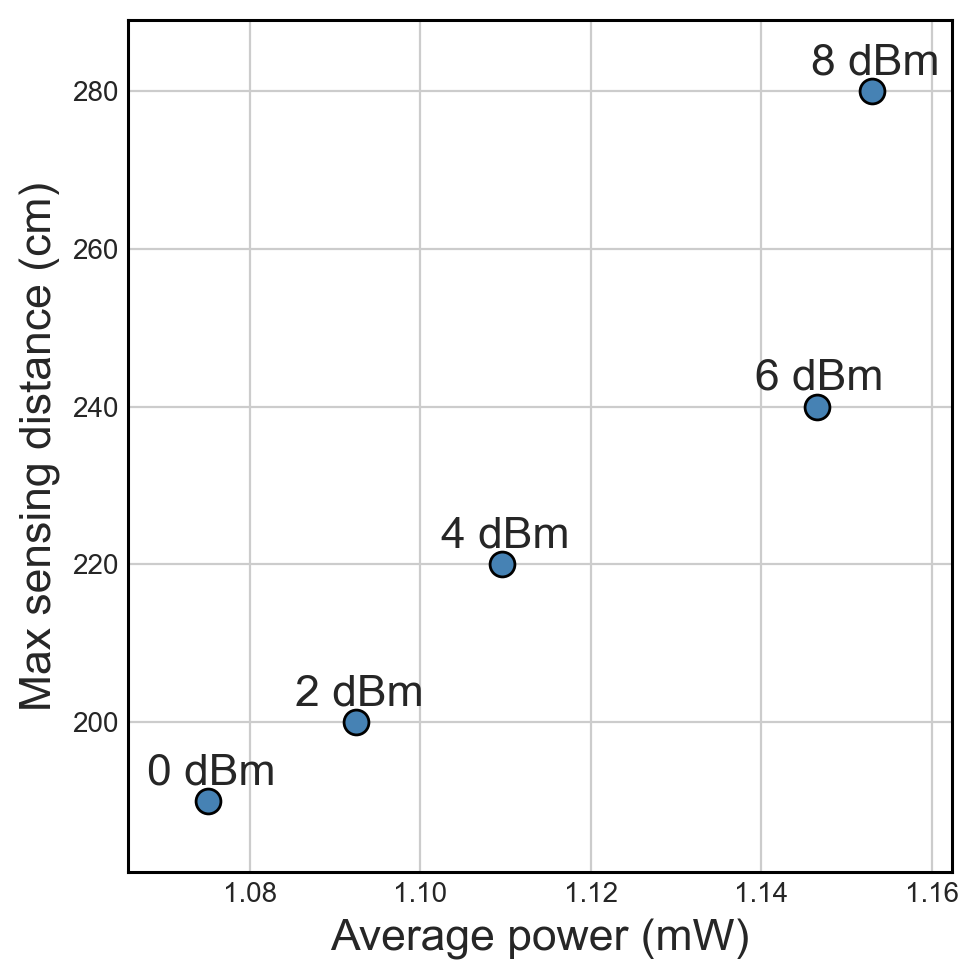

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
out_dir = PROJECT_ROOT / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
# ---- CS data ----
tx_dbm = [0, 2, 4, 6, 8]
max_dist_cm = [190, 200, 220, 240, 280]
avg_power_mw = [1.075086, 1.092474, 1.109556, 1.146474, 1.152972]  # 全CS时段平均电流 (mA)

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(5,5), dpi=200)

# Scatter: x=current, y=distance (no colorbar/legend)
ax.scatter(avg_power_mw, max_dist_cm, s=80, color="steelblue",edgecolors="black",)

# Annotate each point with Tx power
for x, y, p in zip(avg_power_mw, max_dist_cm, tx_dbm):
    ax.annotate(f"{p} dBm", (x, y), textcoords="offset points", xytext=(-22, 6), fontsize=16)

# Black box frame (all spines on + black)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.1)

# ax.set_xlabel("Average current during CS (mA)",fontsize=12)
ax.set_xlabel("Average power (mW)",fontsize=16)
ax.set_ylabel("Max sensing distance (cm)",fontsize=16)
# ax.set_title("Sensing distance vs. average current during CS",fontsize=13, fontweight='bold')
# Optional: make the "upper-left is better" message explicit with axis limits
x_pad = (max(avg_power_mw) - min(avg_power_mw)) * 0.12 or 0.01
y_pad = (max(max_dist_cm) - min(max_dist_cm)) * 0.10 or 5
ax.set_xlim(min(avg_power_mw) - x_pad, max(avg_power_mw) + x_pad)
ax.set_ylim(min(max_dist_cm) - y_pad, max(max_dist_cm) + y_pad)

fig.tight_layout()
# 存储图片

output_path_png = out_dir / f"cs_power_vs_distance.png"
output_path_svg = out_dir / f"cs_power_vs_distance.svg"
output_path_pdf = out_dir / f"cs_power_vs_distance.pdf"
# plt.savefig(output_path_png, dpi=200)  
# plt.savefig(output_path_svg, dpi=200)  
plt.savefig(output_path_pdf, dpi=200) 


plt.show()


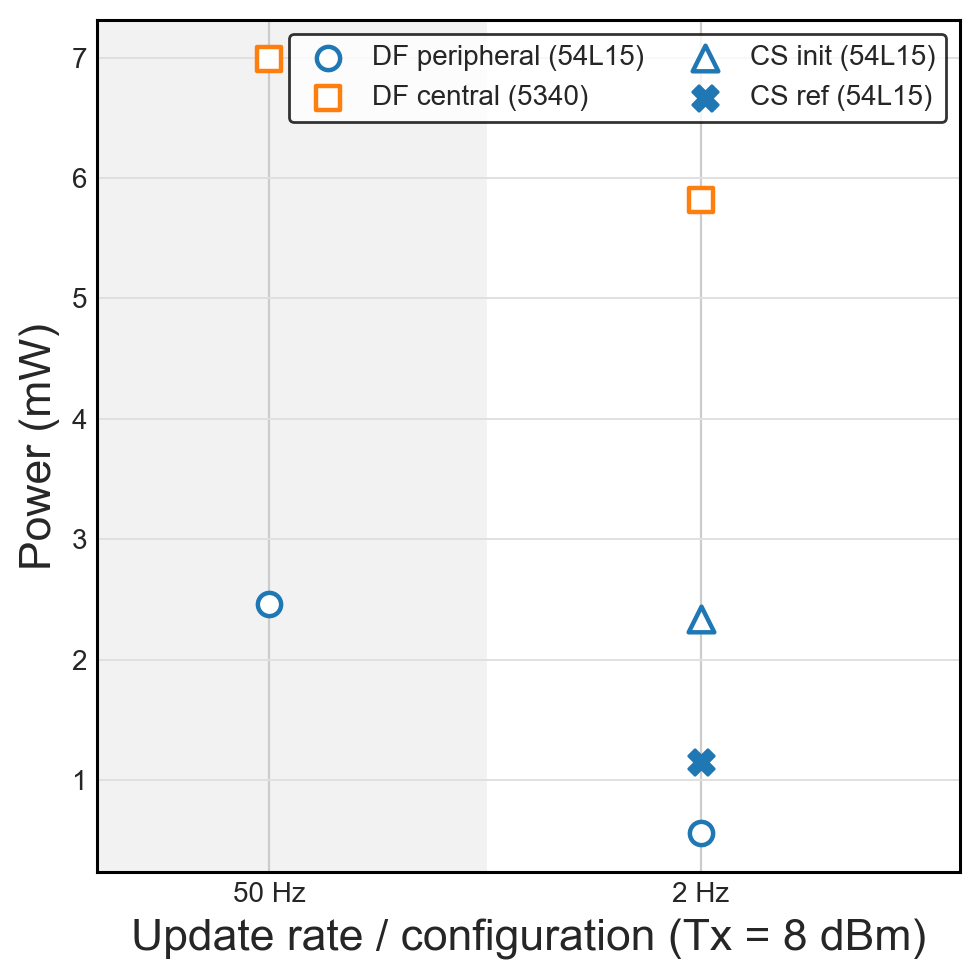

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------- Inputs (confirmed) --------
V_54L15 = 1.8
V_5340 = 3.0

conds = ["50 Hz", "2 Hz"]  # 50 Hz: evt=10ms, CTE=20ms; 2 Hz: evt=250ms, CTE=500ms
x = np.arange(len(conds))

# DF (Tx = 8 dBm)
df_periph_I_54 = np.array([1.37, 0.31])  # 54L15 @1.8V  (DF peripheral)
df_central_I_53 = np.array([2.33, 1.94])  # 5340  @3.0V  (DF central)

# CS references at 8 dBm (device: 54L15)
cs_ref_I_54 = 0.63754  # mA @1.8V
cs_init_I_54 = 1.3  # mA @1.8V

# Convert to power in mW: P(mW) = V(V) * I(mA)
df_periph_P = V_54L15 * df_periph_I_54
df_central_P = V_5340 * df_central_I_53
cs_ref_P = V_54L15 * cs_ref_I_54
cs_init_P = V_54L15 * cs_init_I_54

# -------- Plot styling (paper-like) --------
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.linewidth": 1.1,
    }
)

c_54 = "tab:blue"  # 54L15
c_53 = "tab:orange"  # 5340

fig, ax = plt.subplots(figsize=(5, 5), dpi=200)

# Highlight 50 Hz column subtly (optional, can remove if you want cleaner)
ax.axvspan(-0.5, 0.5, color="0.95", zorder=0)

# DF points (condition-dependent)
ax.scatter(
    x,
    df_periph_P,
    s=70,
    marker="o",
    facecolors="white",
    edgecolors=c_54,
    linewidths=1.6,
    label="DF peripheral (54L15)",
    zorder=3,
)
ax.scatter(
    x,
    df_central_P,
    s=70,
    marker="s",
    facecolors="white",
    edgecolors=c_53,
    linewidths=1.6,
    label="DF central (5340)",
    zorder=3,
)

# CS init/ref as horizontal references + explicit markers
# ax.axhline(cs_init_P, color=c_54, linestyle="--", linewidth=1.2, zorder=1)
# ax.axhline(cs_ref_P,  color=c_54, linestyle=":",  linewidth=1.6, zorder=1)

# Put markers at the right side so legend shows marker styles clearly
x_ref = x[-1] + 0
# x_ref = x
ax.scatter(
    [x_ref],
    [cs_init_P],
    s=85,
    marker="^",
    facecolors="white",
    edgecolors=c_54,
    linewidths=1.6,
    label="CS init (54L15)",
    zorder=4,
)
ax.scatter(
    [x_ref], [cs_ref_P], s=85, marker="X", color=c_54, label="CS ref (54L15)", zorder=4
)

# Axes
ax.set_xticks(x)
ax.set_xticklabels(conds)
ax.set_xlabel("Update rate / configuration (Tx = 8 dBm)", fontsize=16)
ax.set_ylabel("Power (mW)", fontsize=16)
ax.set_xlim(-0.4, x[-1] + 0.60)

# ax.set_title("Power Comparison at 8 dBm",fontsize=13,fontweight='bold')

# Grid + black frame
ax.grid(True, axis="y", color="0.88", linewidth=0.7)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.1)

# Legend: compact, 2 columns
ax.legend(
    frameon=True,
    ncol=2,
    loc="upper right",
    columnspacing=1.2,
    handletextpad=0.6,
    edgecolor="black",
)

fig.tight_layout()

# 存储图片
output_path_png = out_dir / f"Power_Comparison_at_8dBm.png"
output_path_svg = out_dir / f"Power_Comparison_at_8dBm.svg"
output_path_pdf = out_dir / f"Power_Comparison_at_8dBm.pdf"
# plt.savefig(output_path_png, dpi=200)
# plt.savefig(output_path_svg, dpi=200)
plt.savefig(output_path_pdf, dpi=200)

plt.show()

# Optional export
# fig.savefig("power_comparison_tx8dbm.pdf", bbox_inches="tight")